### Homework Assignment 7: Classification
### Ashbah Faisal
### af08271

In [194]:
import pandas as pd
from sklearn import tree #Decision Trees
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

In [196]:
df = pd.read_csv('Admission_Chance_Classification.csv')
df

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Admit
0,337,118,4,4.5,4.5,9.65,YES,YES
1,324,107,4,4.0,4.5,8.87,YES,YES
2,316,104,3,3.0,3.5,8.00,YES,YES
3,322,110,3,3.5,2.5,8.67,YES,YES
4,314,103,2,2.0,3.0,8.21,NO,YES
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,YES,YES
396,325,107,3,3.0,3.5,9.11,YES,YES
397,330,116,4,5.0,4.5,9.45,YES,YES
398,312,103,3,3.5,4.0,8.78,NO,YES


In [198]:
#Q2
np.random.seed(99)

In [200]:
#Q1
X = df.drop(['Admit'], axis=1)
X = pd.get_dummies(X, columns=['Research'], dtype=int) 
X
y = df['Admit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)

['YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES' 'NO' 'YES' 'YES' 'YES'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES' 'NO' 'YES' 'YES' 'NO'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES'
 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES'
 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'YES' 'YES'
 'YES' 'NO' 'YES' 'YES' 'YES' 'YES' 'YES' 'YES' 'NO' 'YES' 'YES' 'YES']
0.8916666666666667
|--- feature_5 <= 7.85
|   |--- feature_4 <= 2.75
|   |   |--- feature_0 <= 301.50
|   |   |   |--- class: NO
|   |   |--- feature_0 >  301.50
|   |   |   |--- feature_5 <= 7.57
|   |   |   |   |--- feature_0 <= 313.50
|   |   |   |   |   |--- class: YES
|   |   

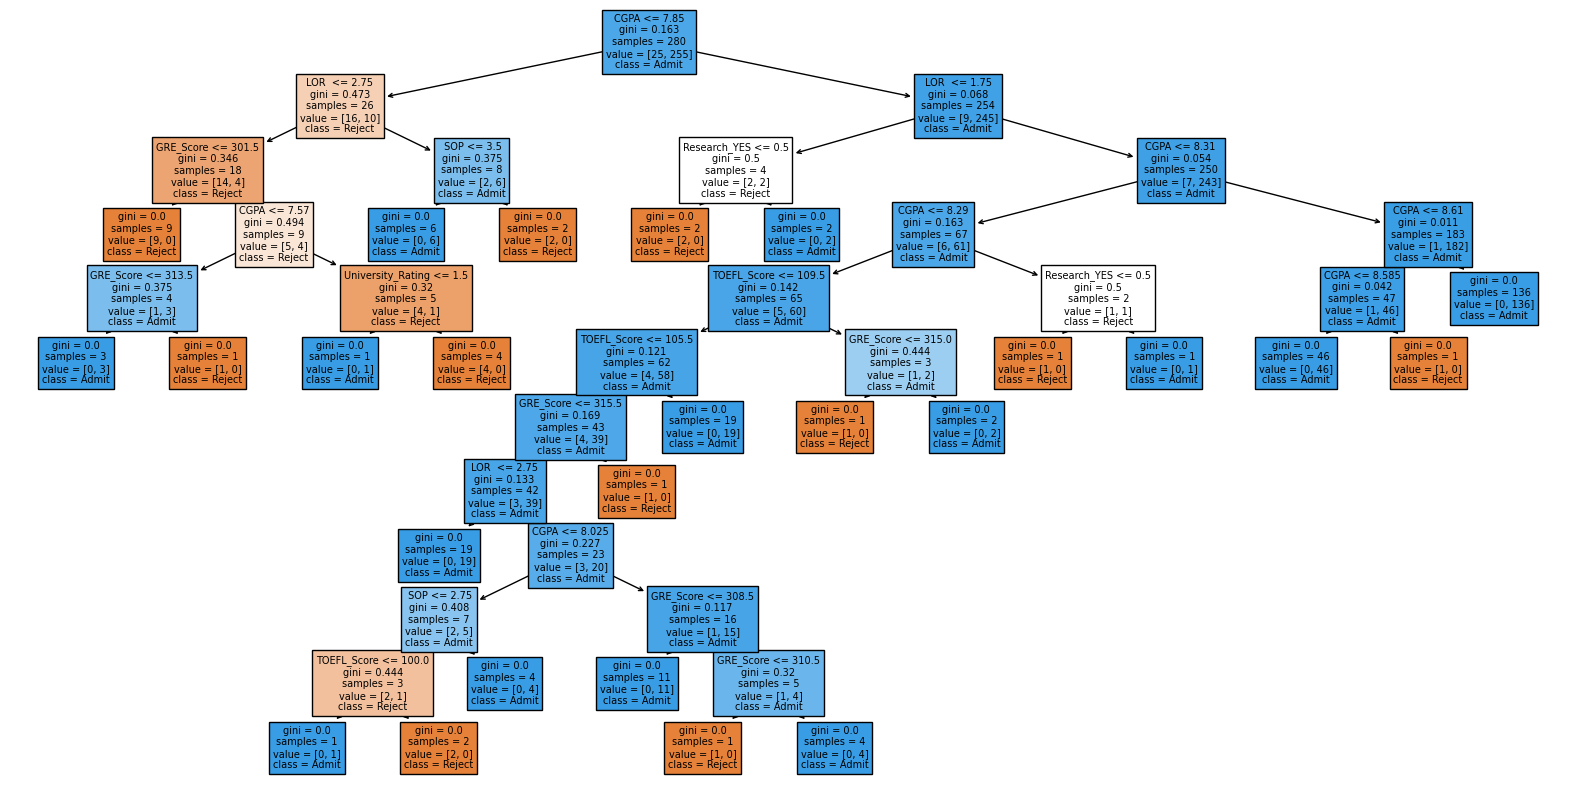

In [202]:
#q3

dt_model = tree.DecisionTreeClassifier(random_state=99)
dt_model.fit(X_train, y_train)

test_pred = dt_model.predict(X_test)
print(test_pred)

acc = accuracy_score(y_test, test_pred)
print(acc)

text_representation = tree.export_text(dt_model)
print(text_representation)

fig=plt.figure(figsize=(20, 10))
_=tree.plot_tree(dt_model, feature_names=X.columns, class_names=['Reject', 'Admit'], filled=True)


### We observe overfitting above because training accuracy is very high and testing accuracy is low. Lets see the tree if it is complex or not. Also the tree is quite complex and the model can definitely use some reduction in the tree's complexity and reduce the overfitting of tree.

In [204]:
#fig.savefig("decistion_tree.png")

train accuracy  100.0
test accuracy 86.66666666666667


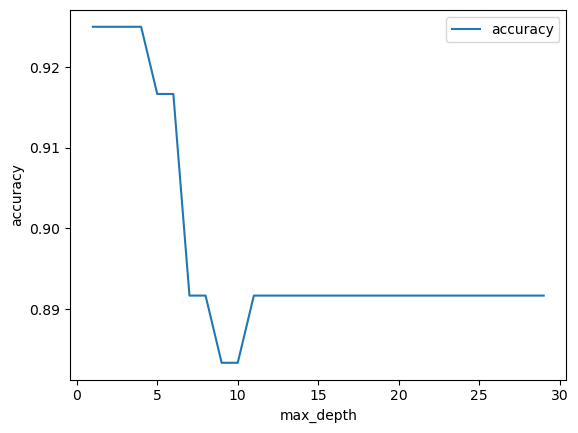

In [205]:
#Q4
dt = tree.DecisionTreeClassifier(criterion='entropy',random_state=99)
dtmodel = dt.fit(X_train, y_train)
train_pred = dtmodel.predict(X_train)
acc = accuracy_score(train_pred, y_train)
print("train accuracy ",acc*100)

test_pred = dtmodel.predict(X_test)
acc = accuracy_score(test_pred, y_test)
print("test accuracy",acc*100)

max_depth = []
acc = []
for i in range(1,30):
    dtree = tree.DecisionTreeClassifier(max_depth=i,random_state=100)
    dtree.fit(X_train, y_train)
    pred = dtree.predict(X_test)
    acc.append(accuracy_score(y_test, pred))
    max_depth.append(i)
    
d = pd.DataFrame({'accuracy':pd.Series(acc),'max_depth':pd.Series(max_depth)})

# visualizing changes in parameters
plt.plot(d['max_depth'].values,d['accuracy'].values)
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.legend(["accuracy"])



#### Very high training set accuracy is a sign of Model Overfitting (see lecture notes). It means model focused too much on training set that it fails to generalize the relationship for test set

train accuracy  98.57142857142858
test accuracy 91.66666666666666


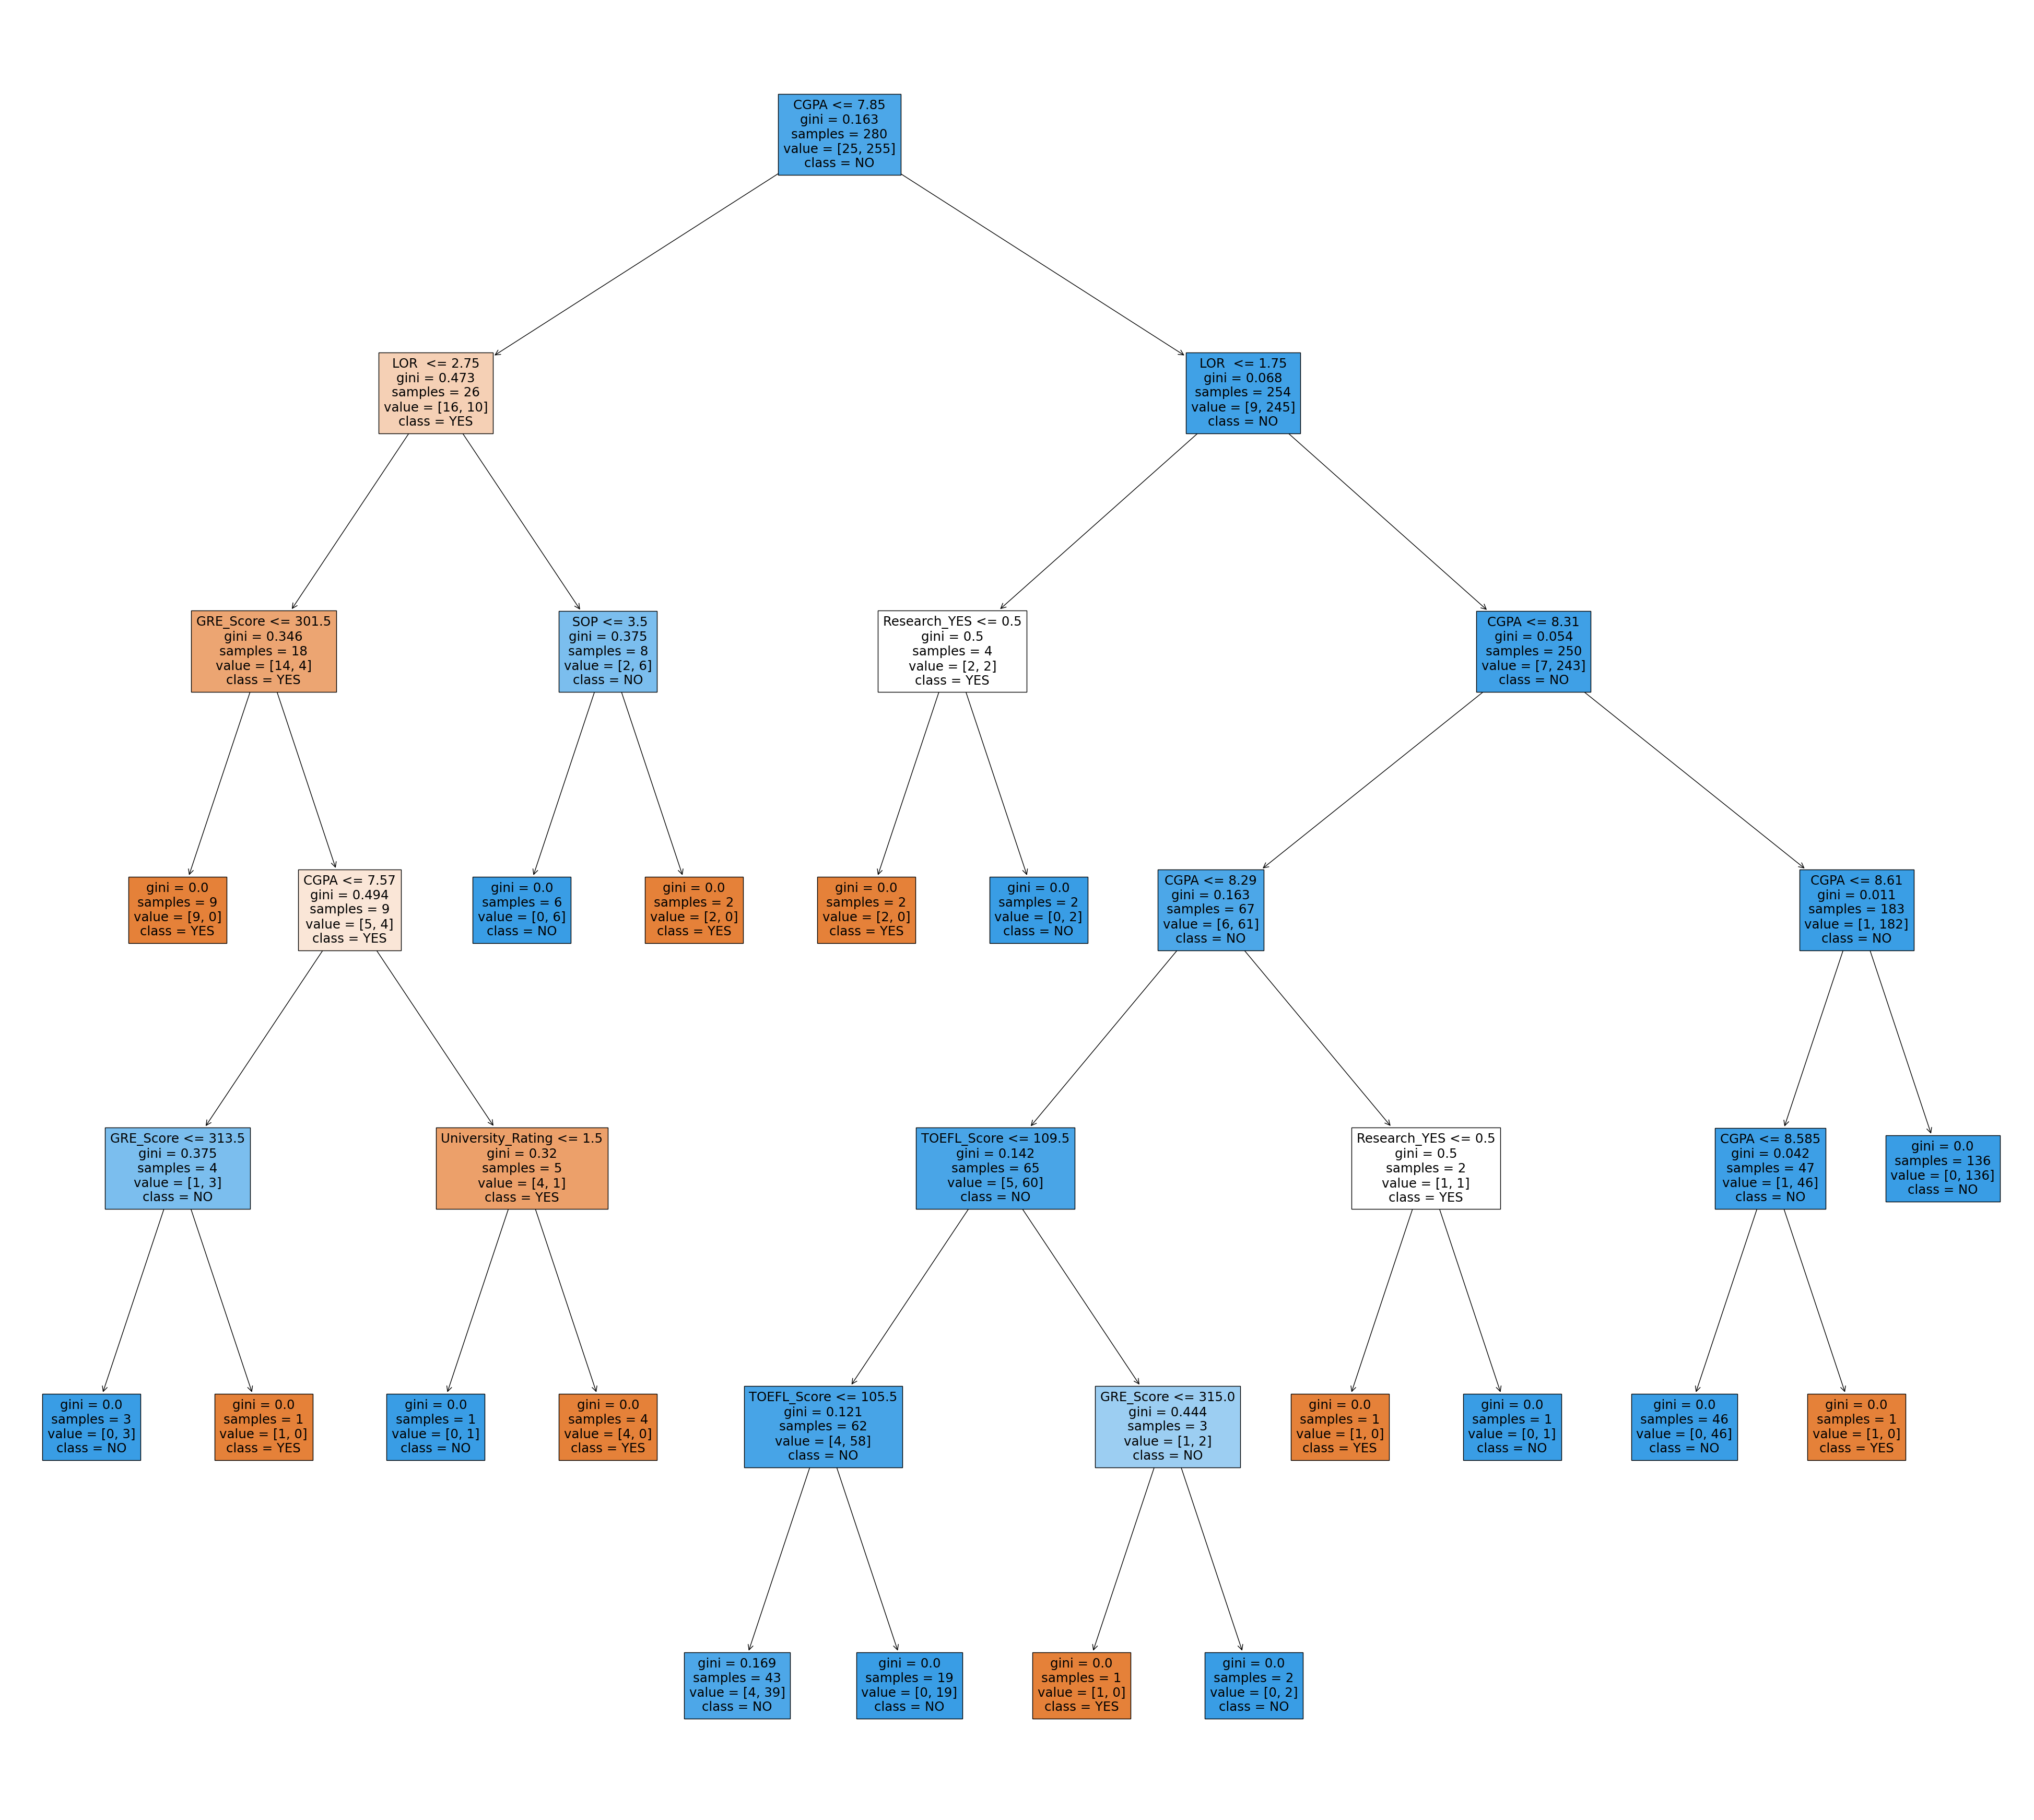

In [209]:
#pruned model
dt = tree.DecisionTreeClassifier(criterion='gini', max_depth=6,random_state=99)

dtmodel = dt.fit(X_train, y_train)
train_pred = dtmodel.predict(X_train)
acc = accuracy_score(train_pred, y_train)
print("train accuracy ",acc*100)

test_pred = dtmodel.predict(X_test)
acc = accuracy_score(test_pred, y_test)
print("test accuracy",acc*100)

fig = plt.figure(figsize=(50,45))
_ = tree.plot_tree(dtmodel, 
                   feature_names=list(X.columns),  
                   class_names=y.value_counts().index,
                   filled=True)

### As shown that the accuracy of the training set is not 100% i.e the model is less over fitted. The pruned model is less complex as shown in the tree above compared to the previous one. The pruned helped increase accuracy on the test data.

n_estimators: 10, Test Accuracy: 91.67%
n_estimators: 50, Test Accuracy: 94.17%
n_estimators: 100, Test Accuracy: 95.00%
n_estimators: 150, Test Accuracy: 95.83%
n_estimators: 200, Test Accuracy: 95.00%


Text(0.5, 0, 'Random Forest Feature Importance')

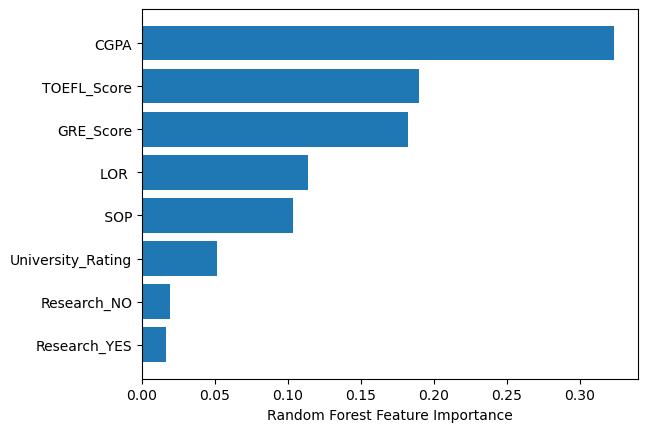

In [212]:
# Q5
n_estimators_values = [10, 50, 100, 150, 200]
results = {}  

for n in n_estimators_values:
    rf_model = RandomForestClassifier(n_estimators=n, random_state=99)
    rf_model.fit(X_train, y_train)
    
    test_pred = rf_model.predict(X_test)
    
    acc = accuracy_score(y_test, test_pred) * 100

    print(f'n_estimators: {n}, Test Accuracy: {acc:.2f}%')

best_rf_model = RandomForestClassifier(n_estimators=150, random_state=99)
best_rf_model.fit(X_train, y_train)

feature_importances =best_rf_model.feature_importances_
sorted_idx = best_rf_model.feature_importances_.argsort()

#plt.barh(list(X.columns), feature_importances)
plt.barh(list(X.columns[sorted_idx]),feature_importances[sorted_idx])
plt.xlabel("Random Forest Feature Importance")

#### The model with 150 estimators achieved the highest accuracy (95.83%), outperforming both 100 estimators (95.00%) and 200 estimators (95.00%). While the 200-tree model didn’t improve accuracy, it adds unnecessary computational complexity. Similarly, the 100-tree model performs slightly worse, making 150 estimators the optimal choice for the best balance between performance and efficiency.

Cross Validation Score for Decission Tree 0.8800000000000001


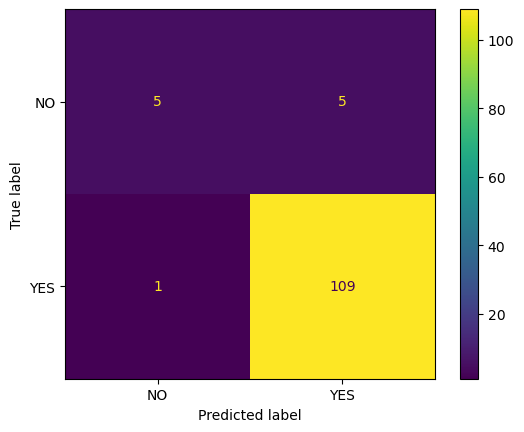

Cross Validation Score for Random Forest 0.925


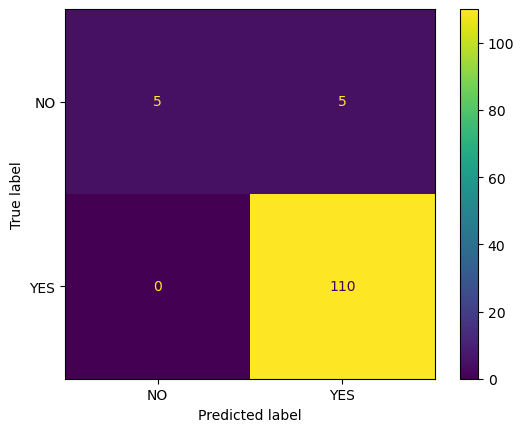

In [214]:
#Q6
score_dt = cross_val_score(dt_model, X, y, cv=5)
score_dt_mean=score_dt.mean()
print("Cross Validation Score for Decission Tree", score_dt_mean)

cm2 = confusion_matrix(y_test, test_pred) 
cp = ConfusionMatrixDisplay(cm2, display_labels=dt.classes_)
cp.plot()
plt.show()

score_rf = cross_val_score(best_rf_model, X, y, cv=5)
score_rf_mean=score_rf.mean()
print("Cross Validation Score for Random Forest", score_rf_mean)

r_test = best_rf_model.predict(X_test)
cm2 = confusion_matrix(y_test, r_test) 
cp = ConfusionMatrixDisplay(cm2, display_labels=best_rf_model.classes_)
cp.plot()
plt.show()



### The Decision Tree model achieved an accuracy of 88%, misclassifying 5 NO samples as YES and 1 YES sample as NO. On the other hand, the RandomForest model improved the accuracy to 92.5%, with the same 5 NO samples misclassified as YES, but no YES samples misclassified as NO. This shows that RandomForest offers better handling of the majority class YES and improved generalization, making it the more reliable model for this classification task.

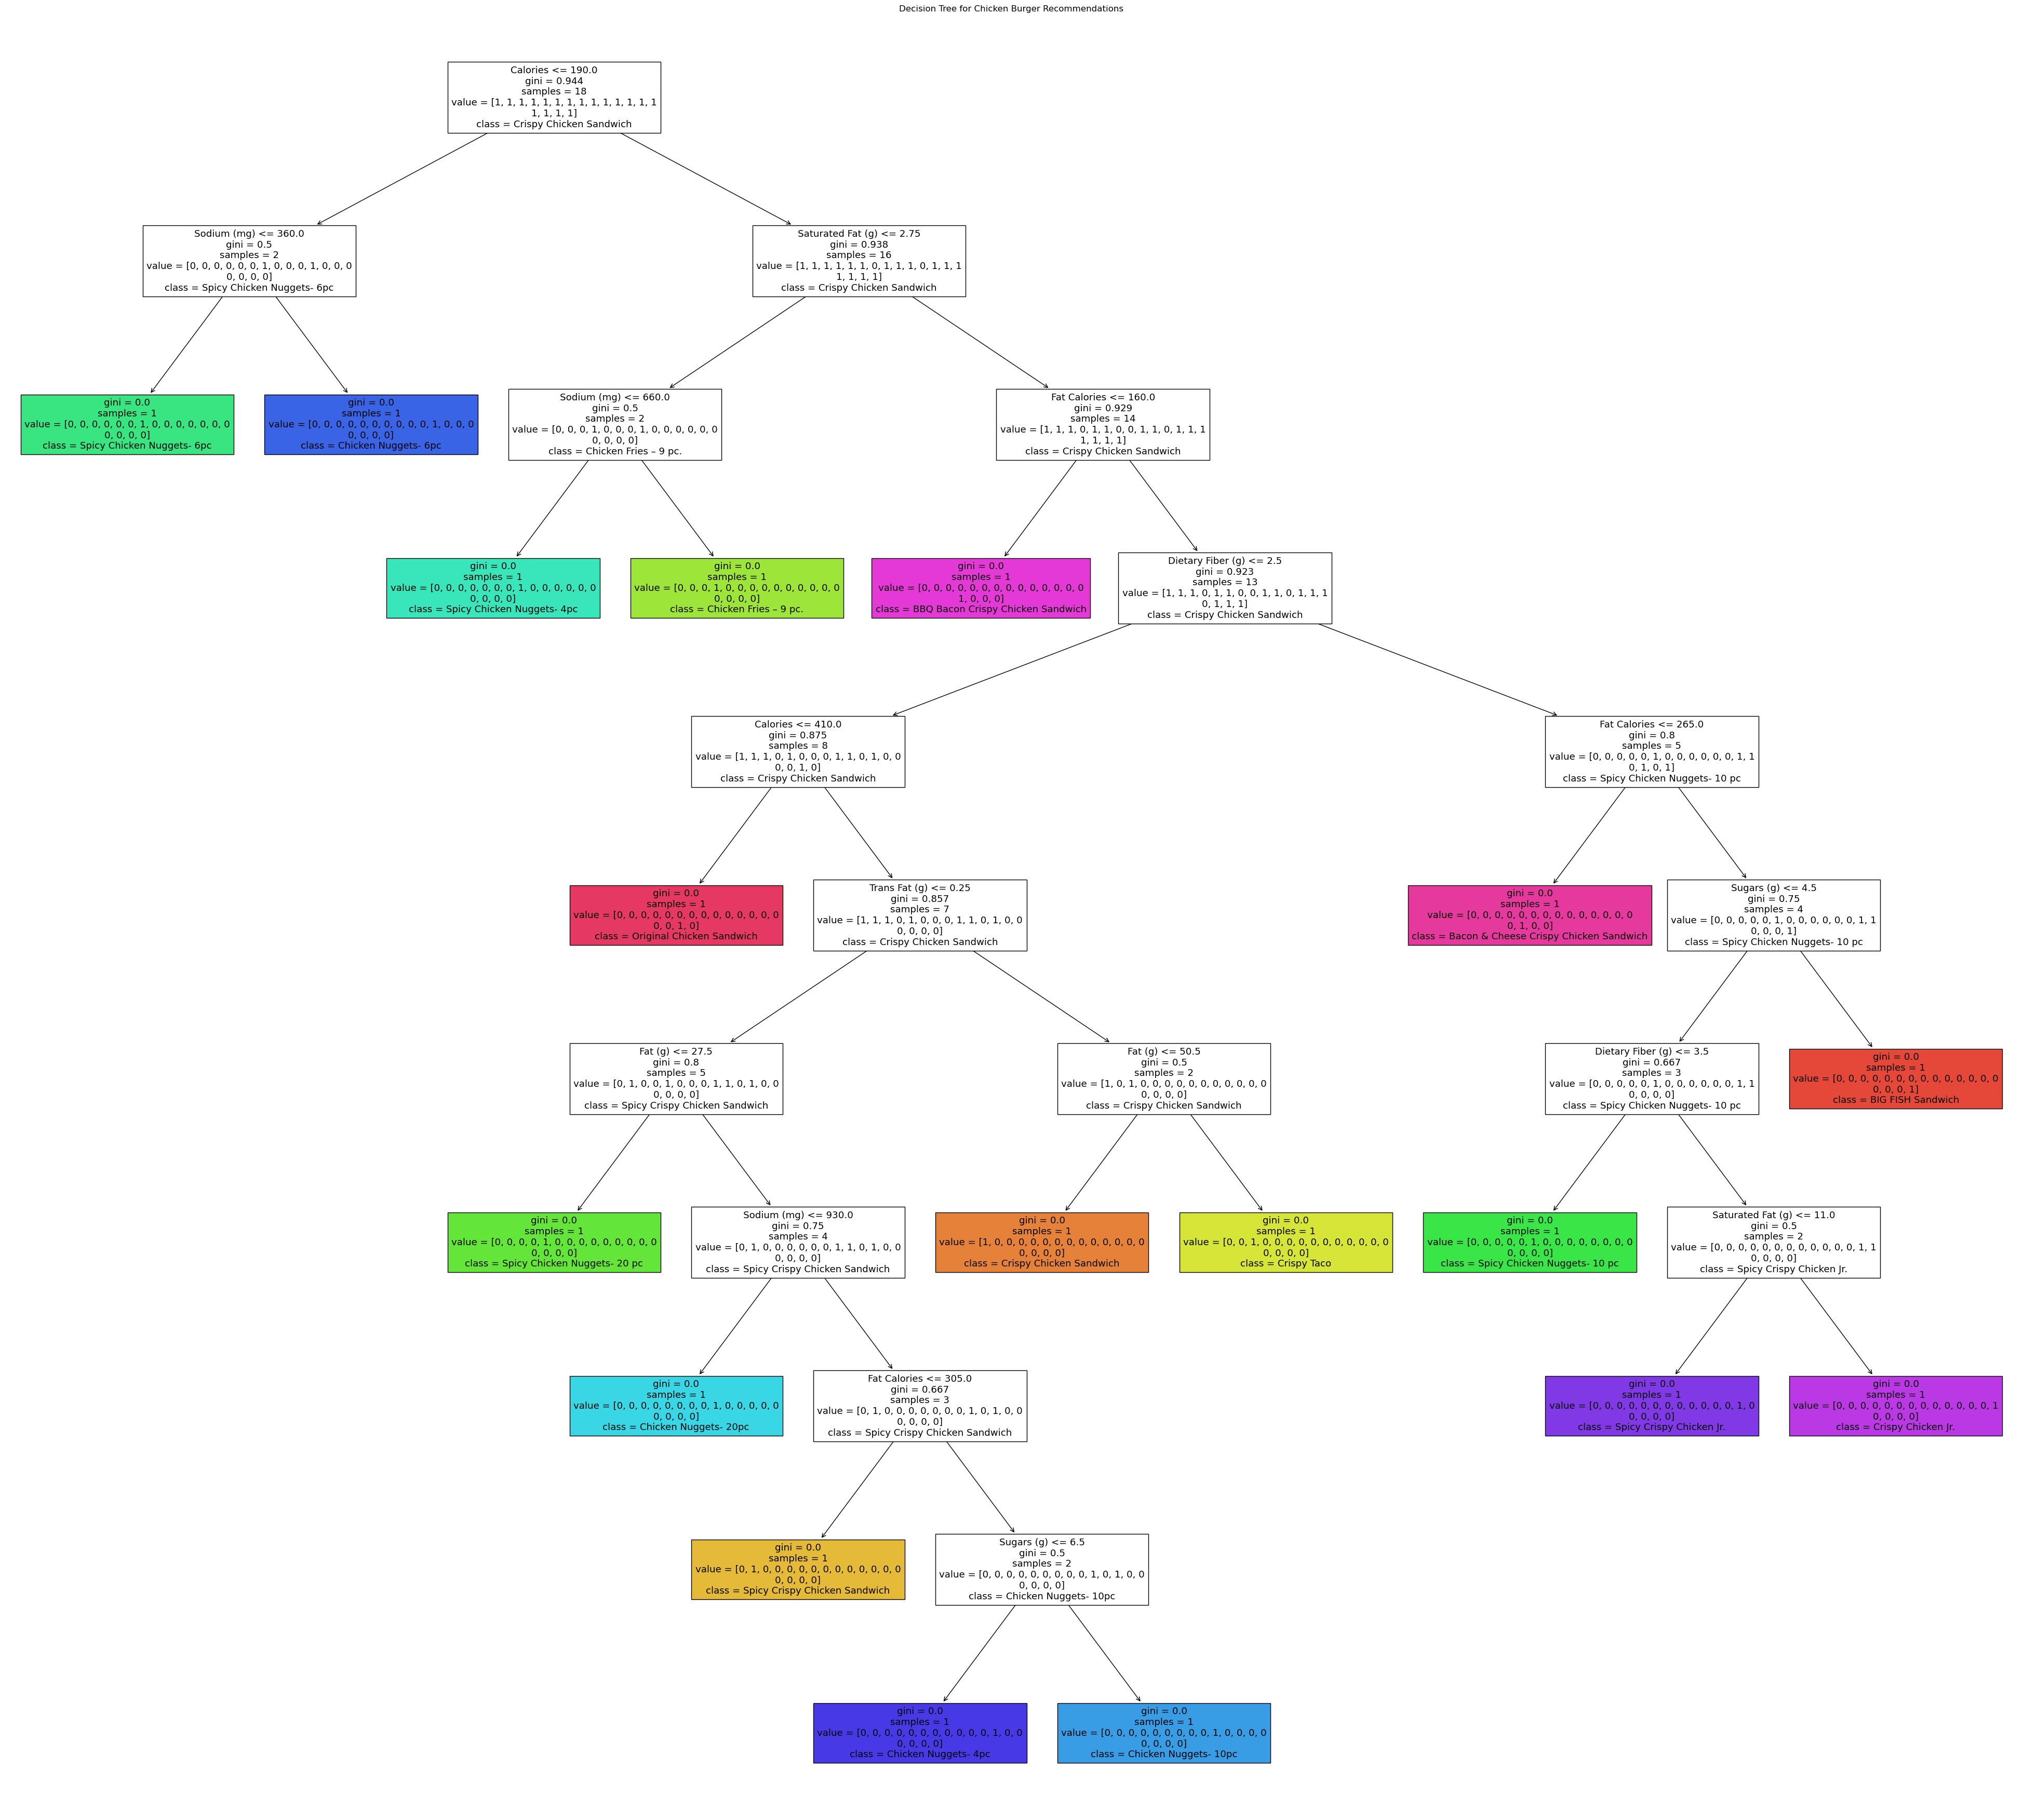

In [217]:
#Q7
data = pd.read_csv("burger-king-menu-2.csv")

chicken_data = data[data['Category'].str.contains('Chicken', case=False)].drop(['Category'], axis=1)

X_chicken = chicken_data.drop(['Item'], axis=1)
y_chicken = chicken_data['Item']

chicken_tree = DecisionTreeClassifier(random_state=99)
chicken_tree.fit(X_chicken, y_chicken)

fig = plt.figure(figsize=(50, 45))
_ = plot_tree(
    chicken_tree,
    feature_names=list(X_chicken.columns),
    class_names=y_chicken.value_counts().index.astype(str),
    filled=True
)
plt.title('Decision Tree for Chicken Burger Recommendations')
plt.show()



### The decision tree recommends chicken items by evaluating attributes such as calories, fat, protein, and cholesterol. For lower-calorie options, it suggests items like Spicy Crispy Chicken Jr. when Calories <= 450 and chicken nuggets <=430 calories depending on the number of pieces. When seeking high-protein content, options like Bacon & Cheese Crispy Chicken Sandwich  Chicken appear with Protein = 30g however its fat is also the highest i.e 52 g and Sodium = 1650 mg. This structure ensures tailored recommendations based on the user's dietary preferences, balancing between light and indulgent meals.